# Visualization Analysis - Shipping Performance

This notebook evaluates shipping behavior across the sales dataset, focusing on delivery mode usage, shipping cost patterns, profitability differences across ship modes, and whether shipping choices are associated with stronger or weaker business outcomes. The goal is not only to summarize shipping operations, but also to identify where fulfillment patterns may be helping or hurting sales and profit performance.

## Contents

- [1. Shipping Overview](#Shipping-Overview)
- [2. Sales and Profit by Ship Mode](#Sales-and-Profit-by-Ship-Mode)
- [3. Shipping Cost Analysis](#Shipping-Cost-Analysis)
- [4. Shipping by Region / Market](#Shipping-by-Region-/-Market)
- [5. Shipping Over Time](#Shipping-Over-Time)
- [6. Order Priority and Fulfillment Patterns](#order-priority-and-fulfillment-patterns)

In [14]:
# Load required libraries
library(tidyverse)
library(janitor)
library(dplyr)
library(ggplot2)
library(skimr)
library(purrr)
library(lubridate)
library(ggrepel)

# Source helper scripts
source("../../R/apply_factors.R")
source("../../R/analysis_helpers.R")
source("../../R/temporal_helpers.R")

# Load data
tables <- list(
  Orders  = readr::read_csv("../../data/processed/Orders.csv"),
  Returns = readr::read_csv("../../data/processed/Returns.csv"),
  People  = readr::read_csv("../../data/processed/People.csv")
)

# Apply factor transformations
tables <- apply_factors(tables)

# Extract tables
orders  <- tables$Orders
returns <- tables$Returns
people  <- tables$People

Rows: 51290 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): order_id, ship_mode, customer_name, segment, state, country, mark...
dbl   (6): sales, quantity, discount, profit, shipping_cost, year
date  (2): order_date, ship_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1173 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): order_id, market
lgl (1): returned

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 14 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): person, region

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the co

In [3]:
theme_set(
    theme_minimal(base_size = 13) +
        theme(
          plot.title = element_text(size = 18, face = "bold"),
          plot.subtitle = element_text(size = 14),
          axis.title = element_text(size = 16),
          axis.text = element_text(size = 14),
          strip.text = element_text(size = 14, face = "bold"),
          legend.title = element_text(size = 16),
          legend.text = element_text(size = 14),
          panel.grid.minor = element_blank()
    )
)

ship_blue  <- "#4C78A8"
ship_orange <- "#F58518"
ship_green <- "#54A24B"
ship_red   <- "#E45756"
ship_neutral <- "#B8B8B8"

## Shipping Overview

### Ship Mode Usage Count

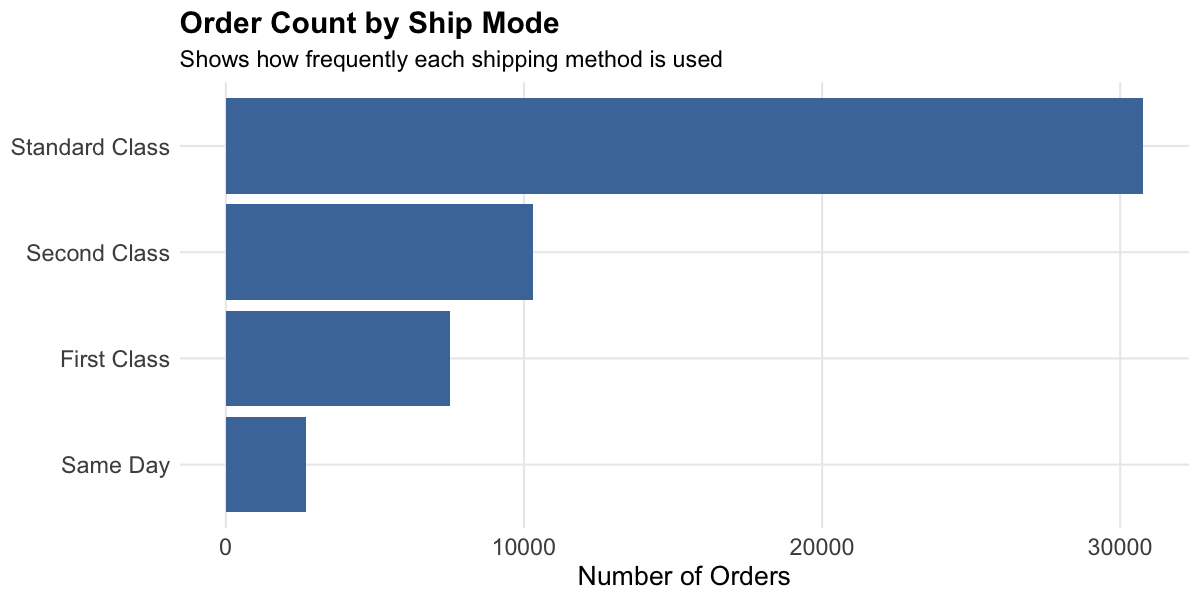

In [36]:
options(repr.plot.width = 10, repr.plot.height = 5)

orders |>
    count(ship_mode, sort = TRUE) |>
    ggplot(aes(x = reorder(ship_mode, n), y = n)) +
    geom_col(fill = ship_blue) +
    coord_flip() +
    labs(
        title = "Order Count by Ship Mode",
        subtitle = "Shows how frequently each shipping method is used",
        x = NULL,
        y = "Number of Orders"
    )

### Total Sales by Ship Mode 

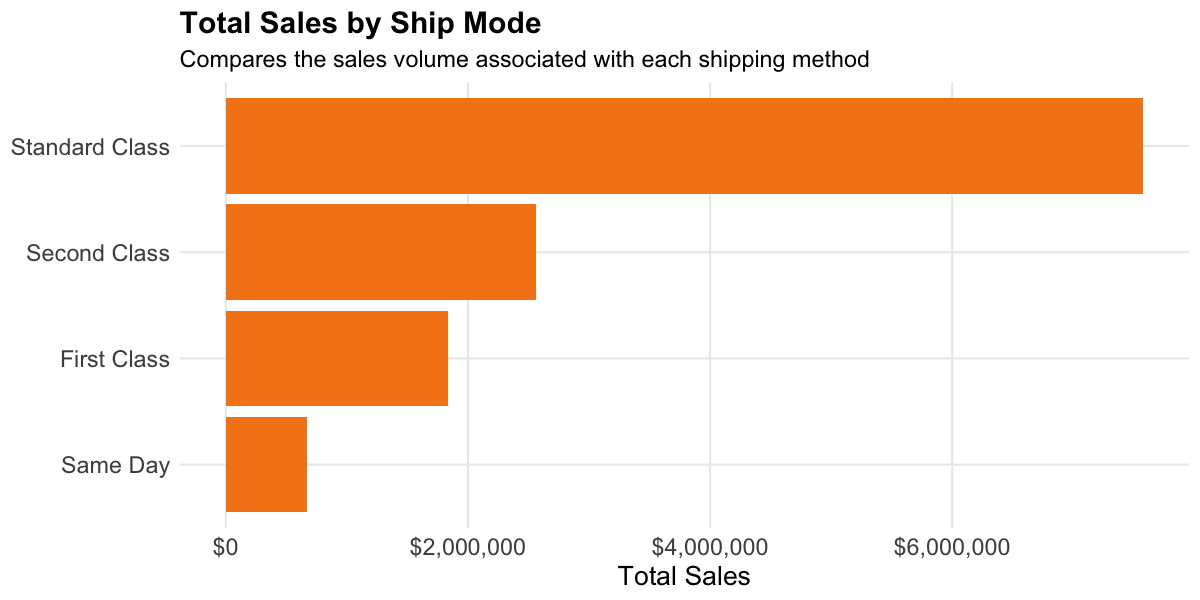

In [7]:
options(repr.plot.width = 10, repr.plot.height = 5)

orders |>
    group_by(ship_mode) |>
    summarise(total_sales = sum(sales, na.rm = TRUE), .groups = "drop") |>
    ggplot(aes(x = reorder(ship_mode, total_sales), y = total_sales)) +
    geom_col(fill = ship_orange) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Sales by Ship Mode",
        subtitle = "Compares the sales volume associated with each shipping method",
        x = NULL,
        y = "Total Sales"
    )

### Average Order Value by Ship Mode

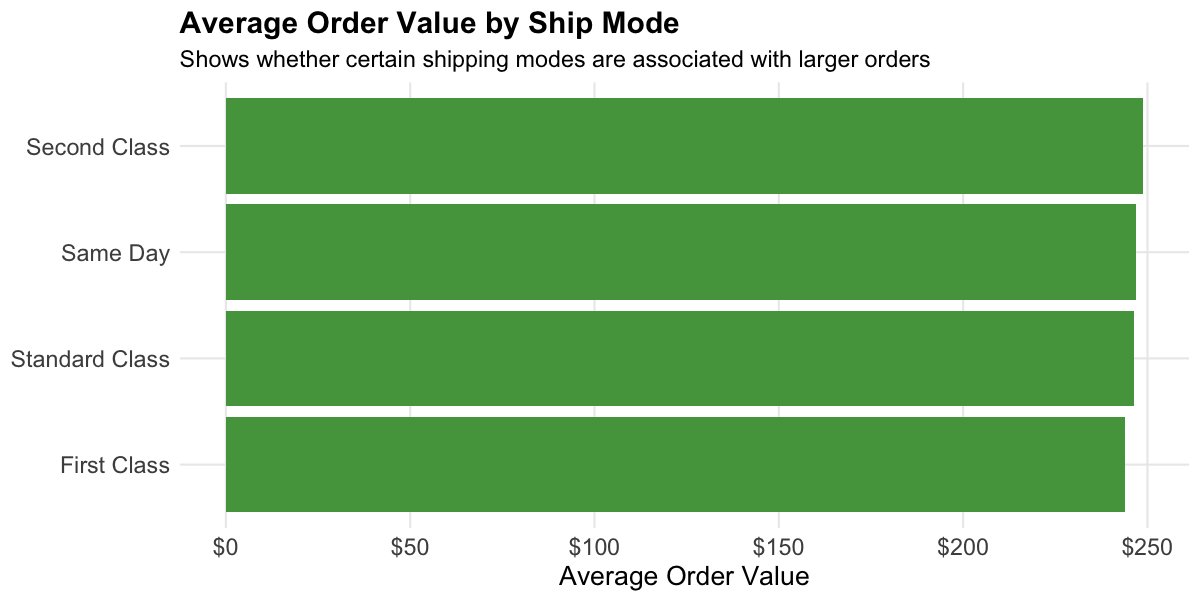

In [8]:
orders |>
    group_by(ship_mode) |>
    summarise(avg_order_value = mean(sales, na.rm = TRUE), .groups = "drop") |>
    ggplot(aes(x = reorder(ship_mode, avg_order_value), y = avg_order_value)) +
    geom_col(fill = ship_green) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Average Order Value by Ship Mode",
        subtitle = "Shows whether certain shipping modes are associated with larger orders",
        x = NULL,
        y = "Average Order Value"
    )

### Section Interpretation

This overview section shows whether shipping behavior is concentrated in one or two dominant modes or more evenly distributed across available options. Order count captures operational usage, while total sales and average order value show whether certain shipping methods are linked to larger commercial activity. In this case we see that the order value is not correlated with shipping mode.

## Sales and Profit by Ship Mode

### Profit by Ship Mode 

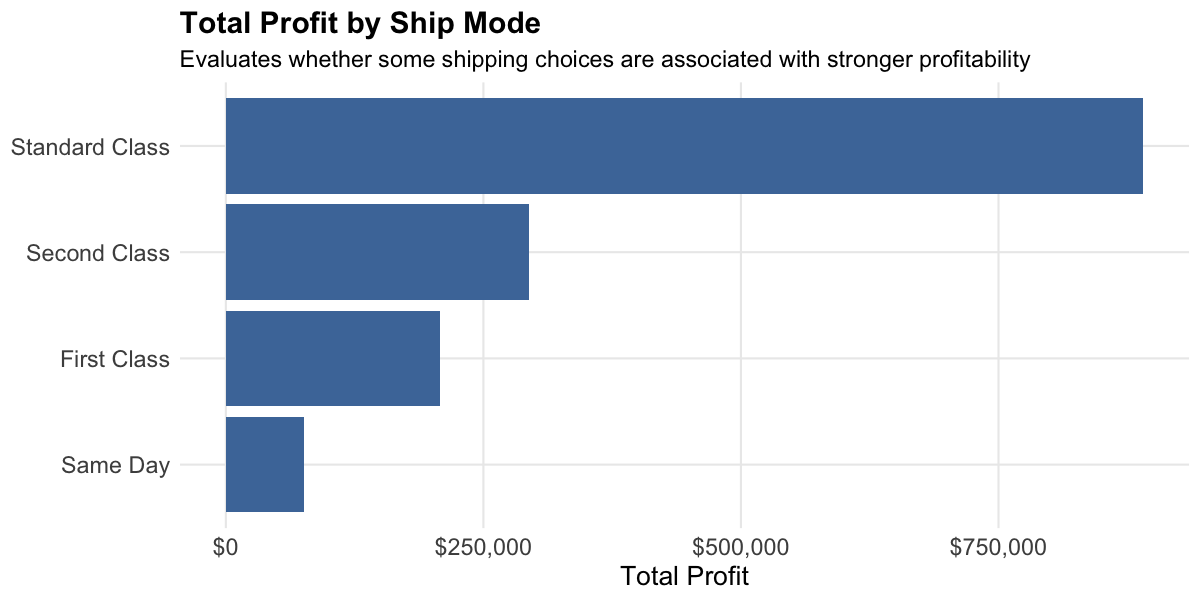

In [9]:
orders |>
    group_by(ship_mode) |>
    summarise(total_profit = sum(profit, na.rm = TRUE), .groups = "drop") |>
    ggplot(aes(x = reorder(ship_mode, total_profit), y = total_profit)) +
    geom_col(fill = ship_blue) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Profit by Ship Mode",
        subtitle = "Evaluates whether some shipping choices are associated with stronger profitability",
        x = NULL,
        y = "Total Profit"
    )

### Profit Margin by Ship Mode

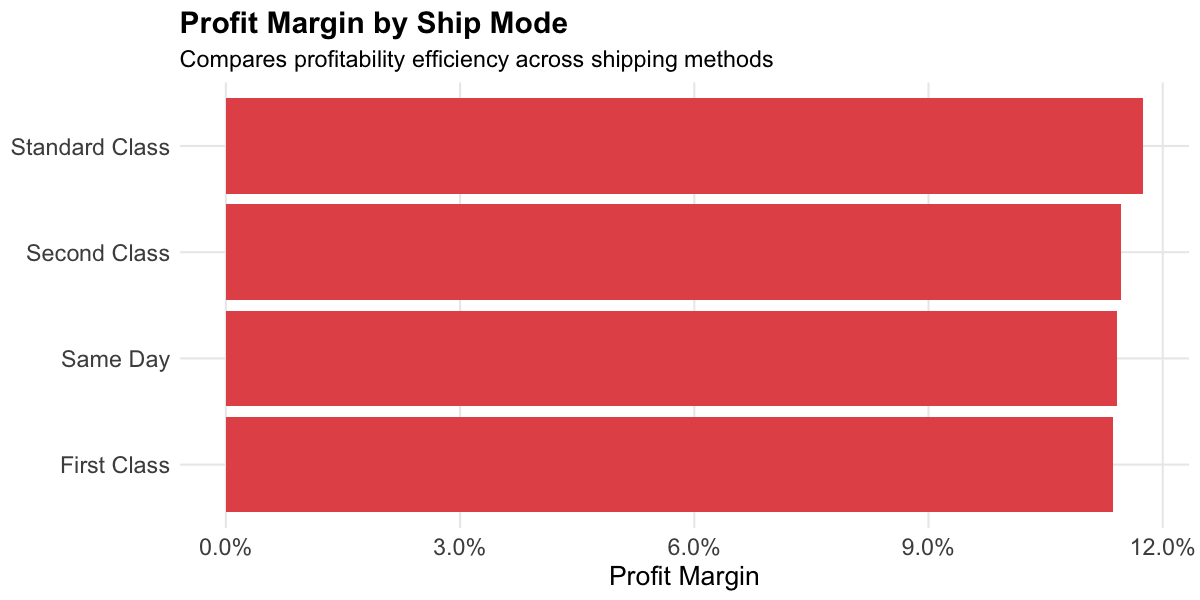

In [10]:
orders |>
    group_by(ship_mode) |>
    summarise(
        total_sales = sum(sales, na.rm = TRUE),
        total_profit = sum(profit, na.rm = TRUE),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    ) |>
    ggplot(aes(x = reorder(ship_mode, profit_margin), y = profit_margin)) +
    geom_col(fill = ship_red) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 0.1)) +
    labs(
        title = "Profit Margin by Ship Mode",
        subtitle = "Compares profitability efficiency across shipping methods",
        x = NULL,
        y = "Profit Margin"
    )

### Sales vs Profit Scatter by Ship Mode

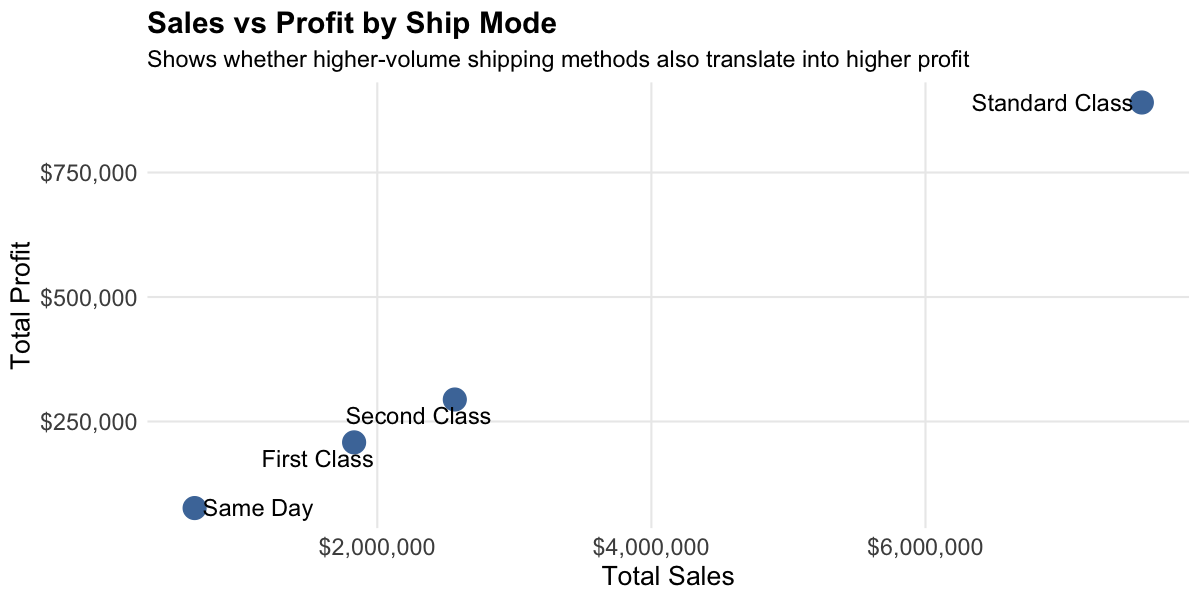

In [19]:
ship_summary <- orders |>
    group_by(ship_mode) |>
    summarise(
        total_sales = sum(sales, na.rm = TRUE),
        total_profit = sum(profit, na.rm = TRUE),
        n_orders = n(),
        .groups = "drop"
    )

ggplot(ship_summary, aes(x = total_sales, y = total_profit, label = ship_mode)) +
    geom_point(size = 6, color = ship_blue) +
    ggrepel::geom_text_repel(size = 5) +
    scale_x_continuous(labels = scales::dollar_format()) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Sales vs Profit by Ship Mode",
        subtitle = "Shows whether higher-volume shipping methods also translate into higher profit",
        x = "Total Sales",
        y = "Total Profit"
    )

### Section Interpretation

This section evaluates whether shipping mode differences are only operational or whether they also matter financially. Total profit shows the absolute contribution of each mode, while profit margin distinguishes between high-volume shipping and efficient shipping. A mode may generate strong sales simply because it is widely used, but the margin view shows whether it is also financially attractive. The combined sales-profit comparison helps identify shipping modes that are commercially important but potentially less efficient, as well as modes that may be lower in scale but stronger in profitability.

## Shipping Cost Analysis

### Average Shipping Cost by Ship Mode

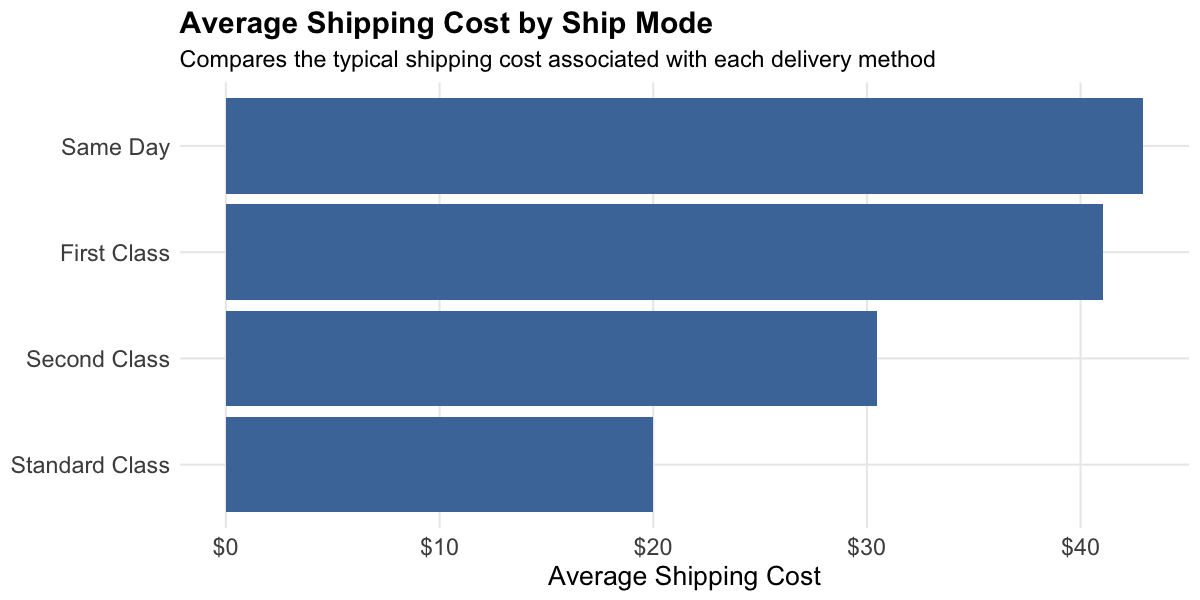

In [35]:
options(repr.plot.width = 10, repr.plot.height = 5)
orders |>
    group_by(ship_mode) |>
    summarise(avg_shipping_cost = mean(shipping_cost, na.rm = TRUE), .groups = "drop") |>
    ggplot(aes(x = reorder(ship_mode, avg_shipping_cost), y = avg_shipping_cost)) +
    geom_col(fill = ship_blue) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Average Shipping Cost by Ship Mode",
        subtitle = "Compares the typical shipping cost associated with each delivery method",
        x = NULL,
        y = "Average Shipping Cost"
    )

### Shipping Cost Distribution by Ship Mode

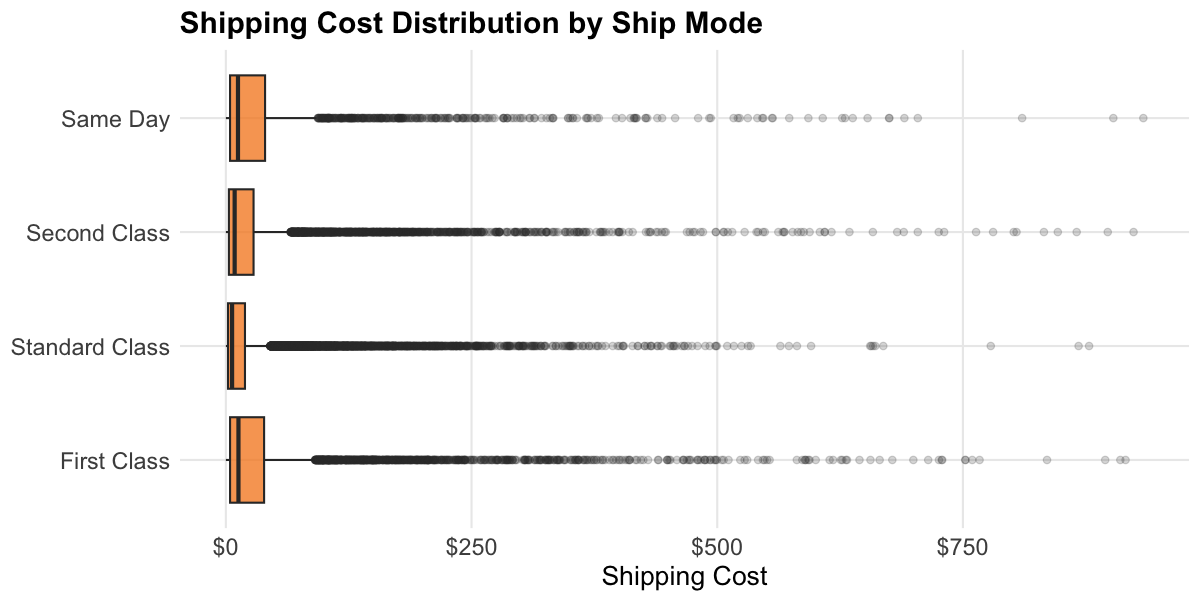

In [41]:
ggplot(orders, aes(x = ship_mode, y = shipping_cost)) +
    geom_boxplot(fill = ship_orange, alpha = 0.75, outlier.alpha = 0.2) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Shipping Cost Distribution by Ship Mode",
        x = NULL,
        y = "Shipping Cost"
    )

### Shipping Cost vs Sales

`geom_smooth()` using formula = 'y ~ x'


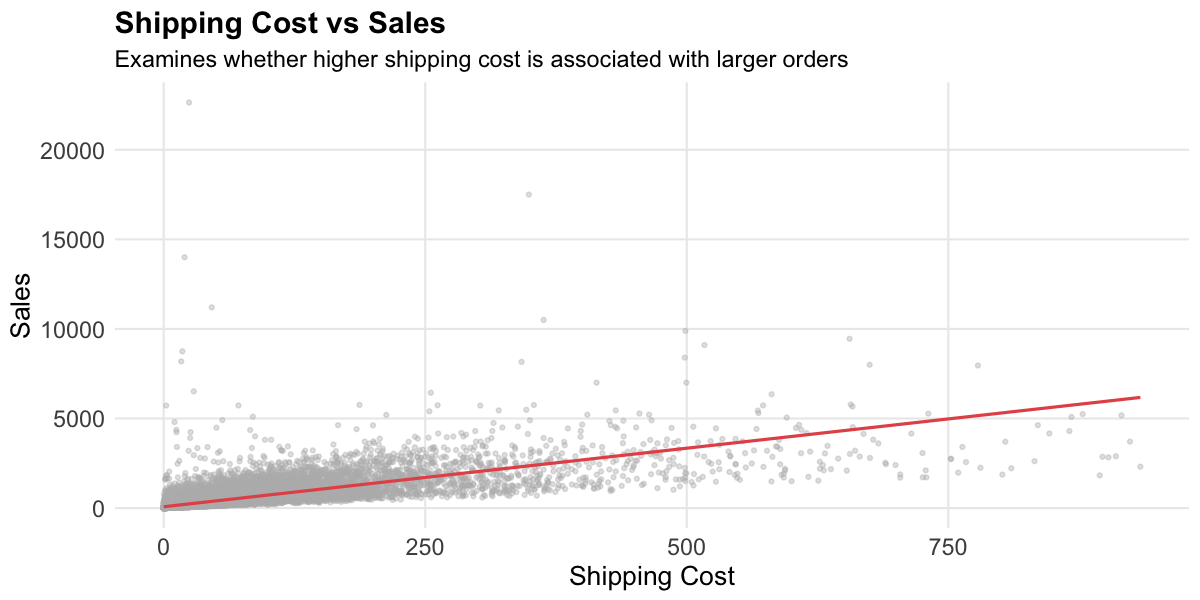

In [39]:
ggplot(orders, aes(x = shipping_cost, y = sales)) +
    geom_point(alpha = 0.4, color = ship_neutral, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = ship_red, linewidth = 0.9) +
    labs(
        title = "Shipping Cost vs Sales",
        subtitle = "Examines whether higher shipping cost is associated with larger orders",
        x = "Shipping Cost",
        y = "Sales"
    )

### Shipping Cost vs Profit

`geom_smooth()` using formula = 'y ~ x'


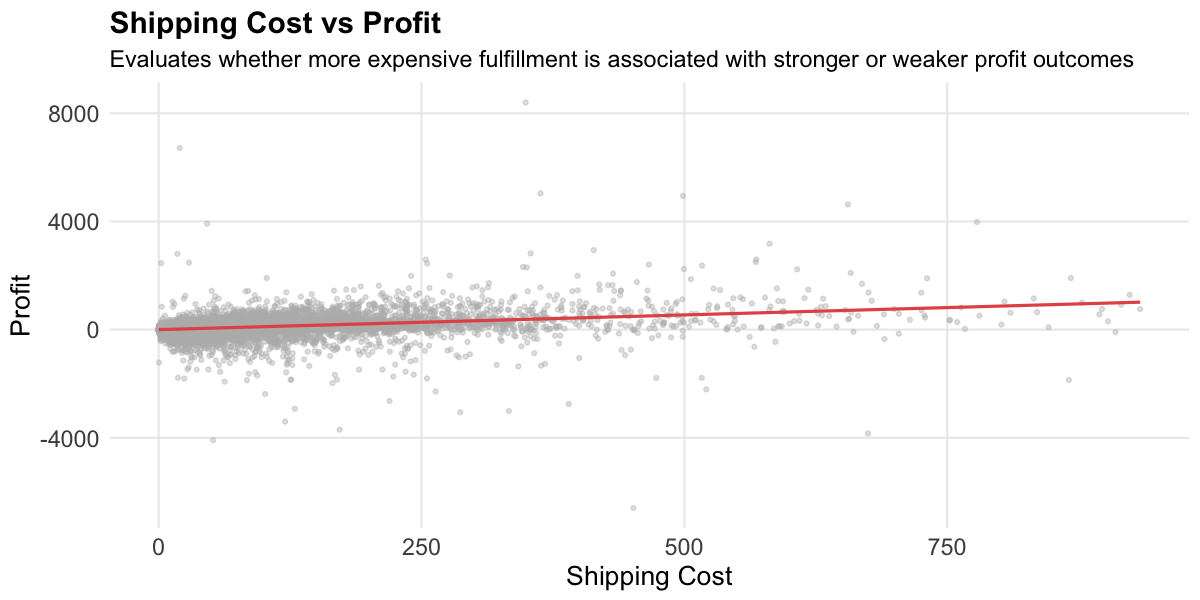

In [38]:
ggplot(orders, aes(x = shipping_cost, y = profit)) +
    geom_point(alpha = 0.4, color = ship_neutral, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = ship_red, linewidth = 0.9) +
    labs(
        title = "Shipping Cost vs Profit",
        subtitle = "Evaluates whether more expensive shipping is associated with stronger or weaker profit outcomes",
        x = "Shipping Cost",
        y = "Profit"
    )

### Profit Distribution by Ship Mode

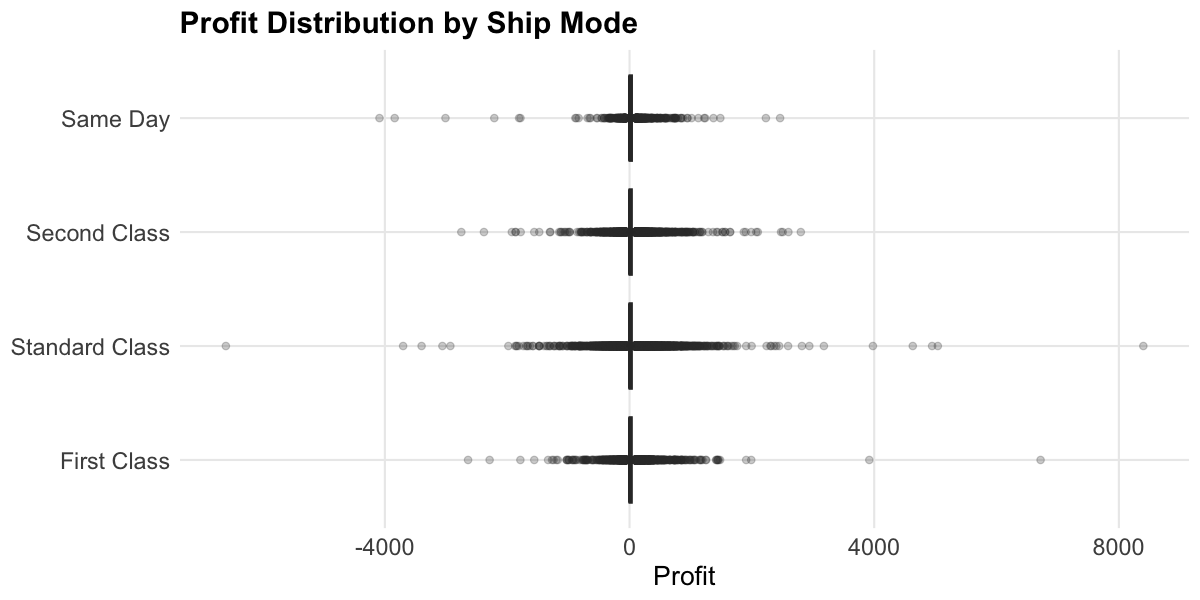

In [21]:
ggplot(orders, aes(x = ship_mode, y = profit)) +
    geom_boxplot(fill = ship_blue, alpha = 0.7, outlier.alpha = 0.25) +
    coord_flip() +
    labs(
        title = "Profit Distribution by Ship Mode",
        x = NULL,
        y = "Profit"
    )

### Discount vs Profit by Ship Mode

`geom_smooth()` using formula = 'y ~ x'


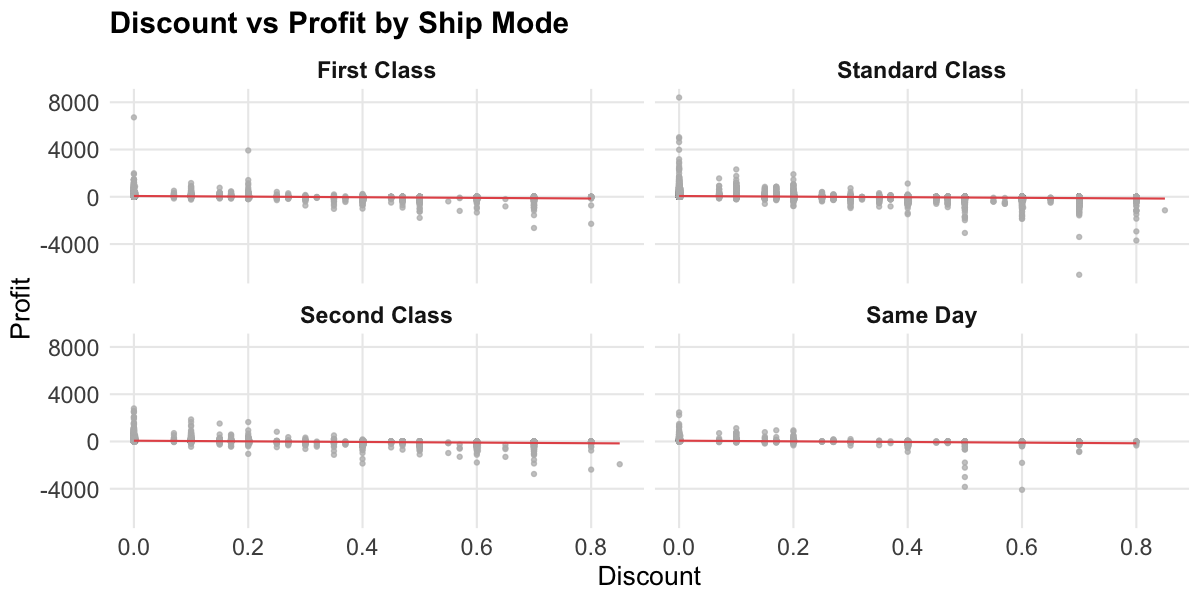

In [26]:
ggplot(orders, aes(x = discount, y = profit)) +
    geom_point(alpha = 0.75, color = ship_neutral, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = ship_red, linewidth = 0.6) +
    facet_wrap(~ ship_mode) +
    labs(
        title = "Discount vs Profit by Ship Mode",
        x = "Discount",
        y = "Profit"
    )

### Section Interpretation

The average and distribution plots show whether some ship modes are consistently more expensive and whether that expense is stable or highly variable across orders. The scatterplots then connect cost to business performance by testing whether higher shipping cost tends to accompany larger orders, stronger profit, or instead weaker financial outcomes. This helps distinguish shipping modes that are expensive but justified from those that may be costly without corresponding business value. Shipping performance should not be understood only in terms of scale; the variability and efficiency of order-level outcomes matter as well. The profit distribution shows whether some shipping modes are associated with more stable order performance or with larger downside risk. The discount-profit relationship adds another efficiency lens by showing whether aggressive discounting within certain shipping methods is associated with weaker profitability. 

## Shipping by Region/Market

### Ship Mode by Region Heatmap

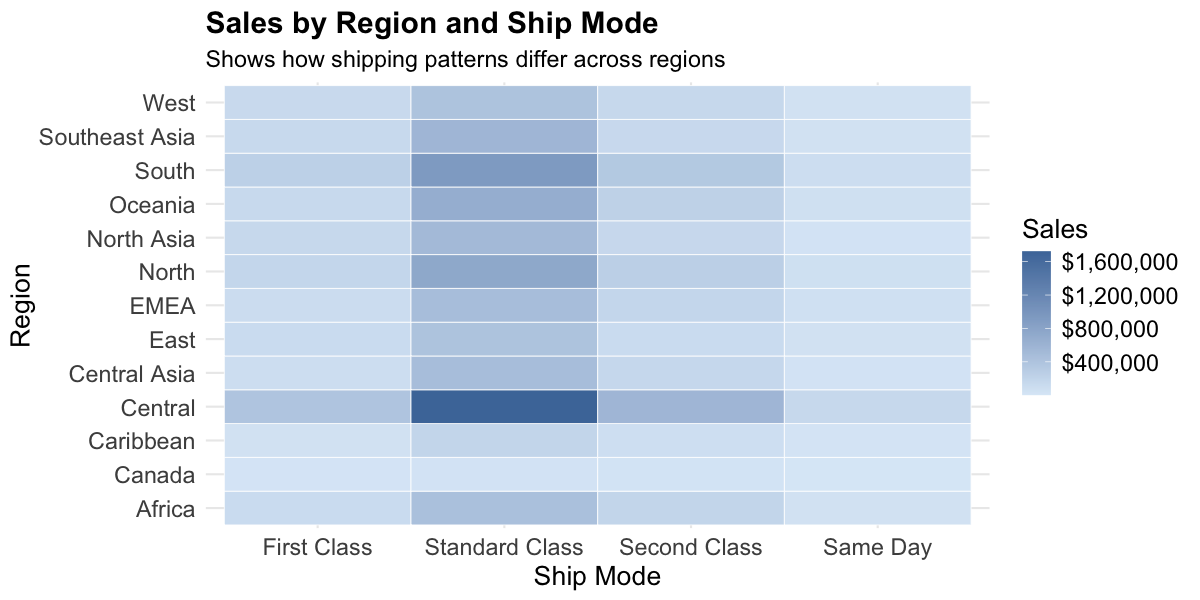

In [27]:
ship_region <- orders |>
    group_by(region, ship_mode) |>
    summarise(total_sales = sum(sales, na.rm = TRUE), .groups = "drop")

ggplot(ship_region, aes(x = ship_mode, y = region, fill = total_sales)) +
    geom_tile(color = "white") +
    scale_fill_gradient(low = "#DCEAF7", high = "#4C78A8", labels = scales::dollar_format()) +
    labs(
        title = "Sales by Region and Ship Mode",
        subtitle = "Shows how shipping patterns differ across regions",
        x = "Ship Mode",
        y = "Region",
        fill = "Sales"
    )

### World Map by Dominant Ship Mode per Country

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `region_clean = countrycode(region, origin = "country.name",
  destination = "country.name")`.
Caused by warning:
! Some values were not matched unambiguously: Ascension Island, Azores, Barbuda, Bonaire, Canary Islands, Chagos Archipelago, Grenadines, Heard Island, Madeira Islands, Micronesia, Saba, Saint Martin, Siachen Glacier, Sint Eustatius, Virgin Islands
To fix unmatched values, please use the `custom_match` argument. If you think the default matching rules should be improved, please file an issue at https://github.com/vincentarelbundock/countrycode/issues”


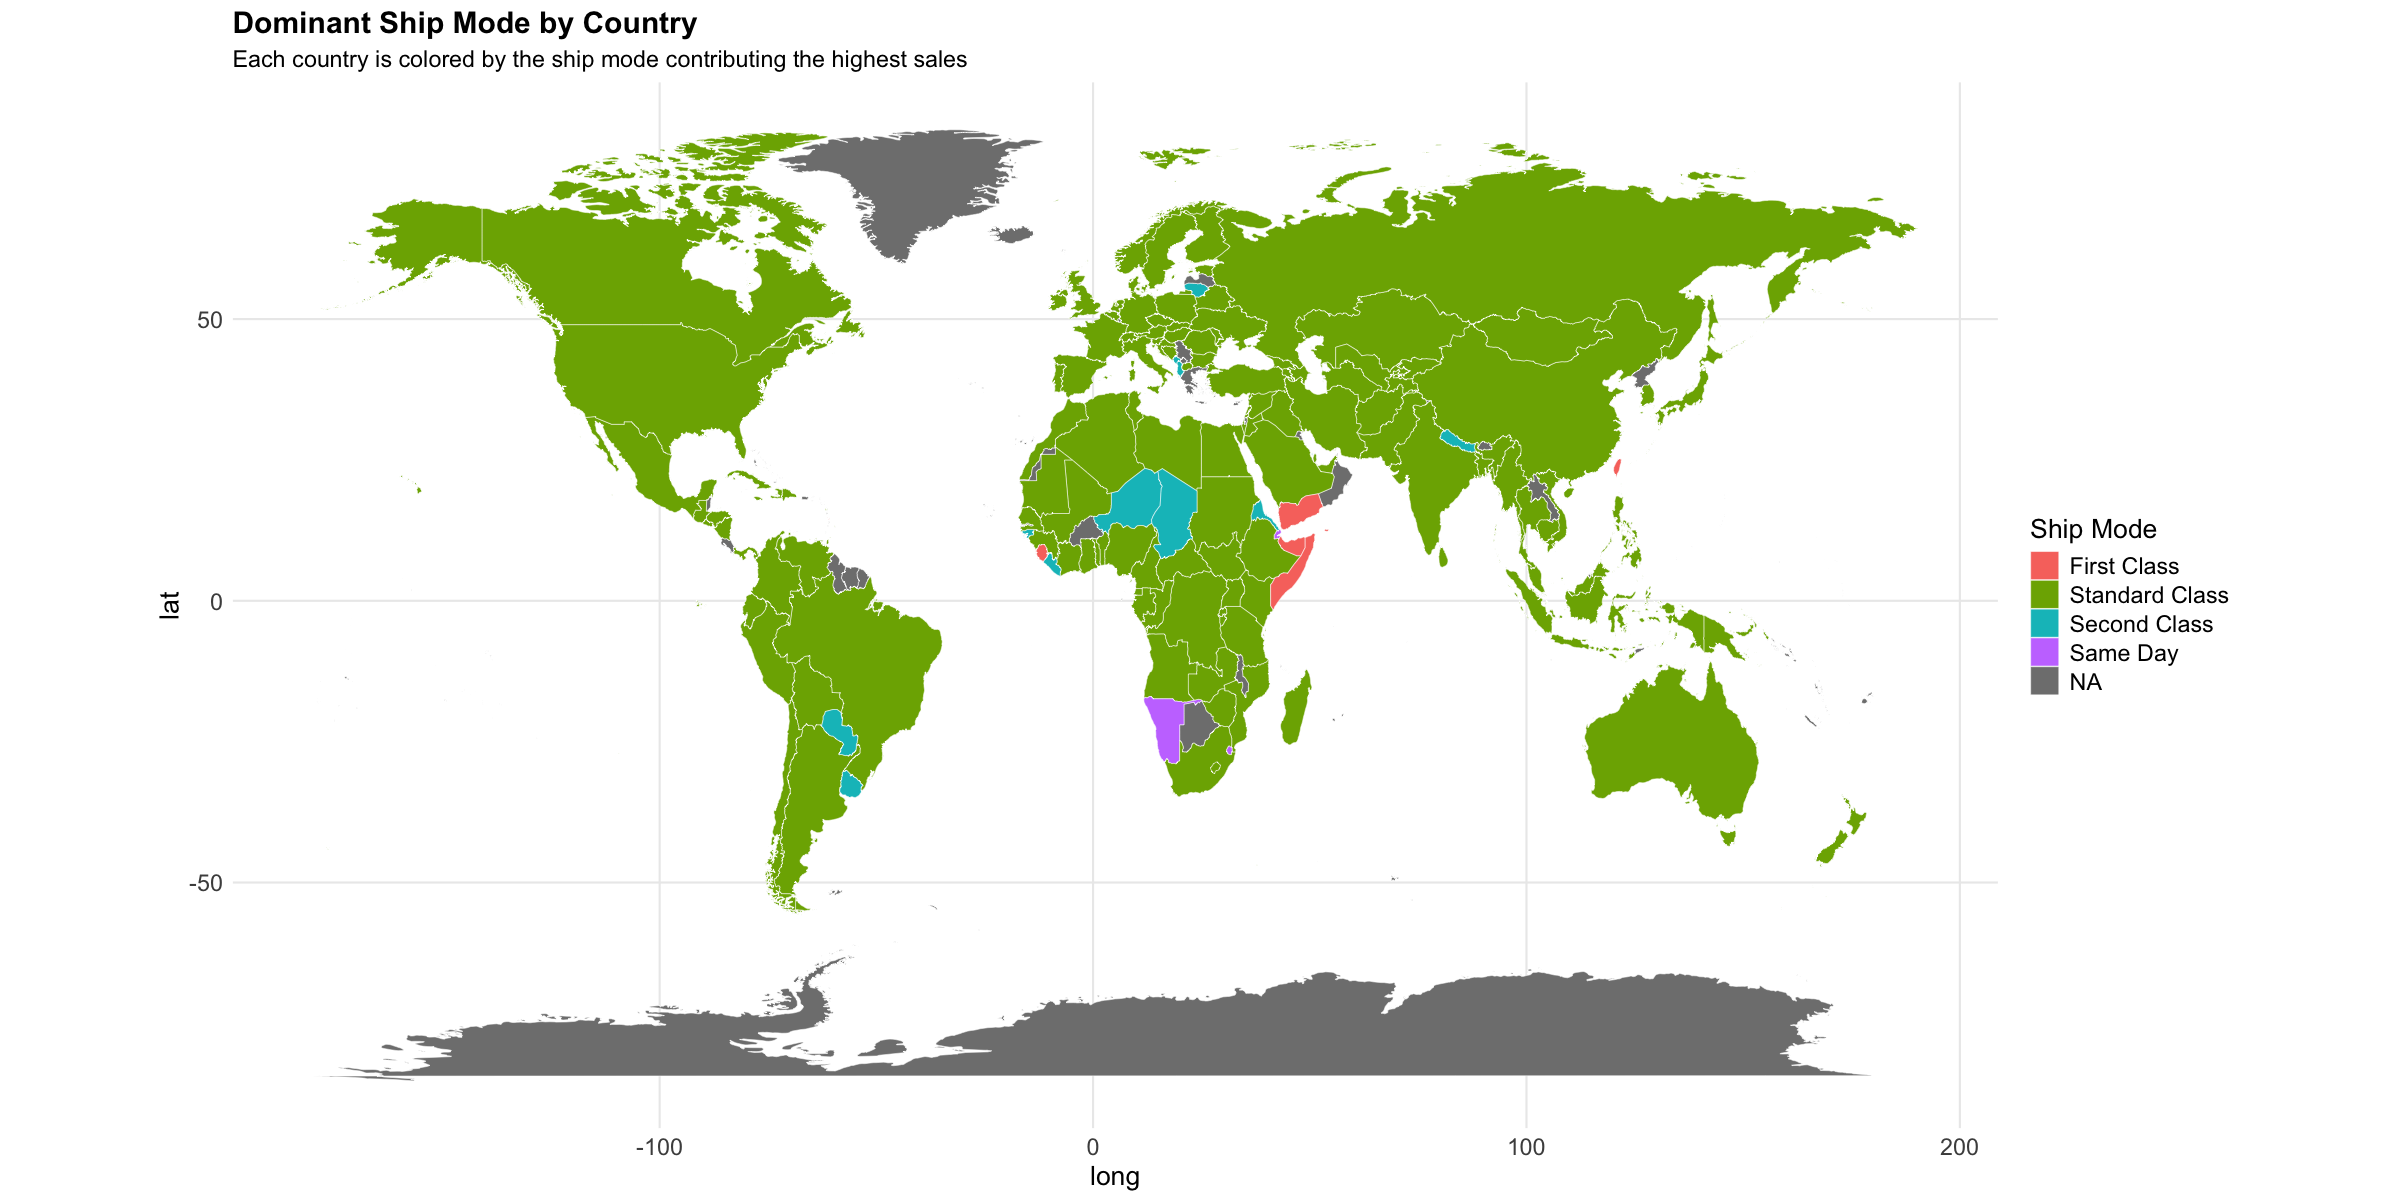

In [31]:
library(countrycode)
library(maps)

country_ship <- orders |>
    filter(!is.na(country), !is.na(ship_mode)) |>
    group_by(country, ship_mode) |>
    summarise(total_sales = sum(sales, na.rm = TRUE), .groups = "drop") |>
    group_by(country) |>
    slice_max(order_by = total_sales, n = 1, with_ties = FALSE) |>
    ungroup() |>
    mutate(country_plot = countrycode(country, origin = "country.name", destination = "country.name"))

world_map <- map_data("world") |>
    mutate(region_clean = countrycode(region, origin = "country.name", destination = "country.name"))

map_df <- world_map |>
    left_join(country_ship, by = c("region_clean" = "country_plot"))

options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(map_df, aes(long, lat, group = group, fill = ship_mode)) +   
    geom_polygon(color = "white", linewidth = 0.15) +
    coord_fixed(1.3) +
    labs(
        title = "Dominant Ship Mode by Country",
        subtitle = "Each country is colored by the ship mode contributing the highest sales",
        fill = "Ship Mode"
    ) 

### Section Interpretation

The geographic view shows whether shipping preferences are globally consistent or whether they differ across regions and countries. The heatmap makes it easier to compare shipping patterns directly across regions, while the optional world map highlights which shipping mode dominates sales in each country. If strong regional variation is present, then shipping decisions may reflect local fulfillment conditions, customer expectations, or infrastructure constraints rather than a single global shipping strategy. This section therefore connects operational shipping choices to geographic business context.

## Shipping over Time

### Ship Mode Usage over Time

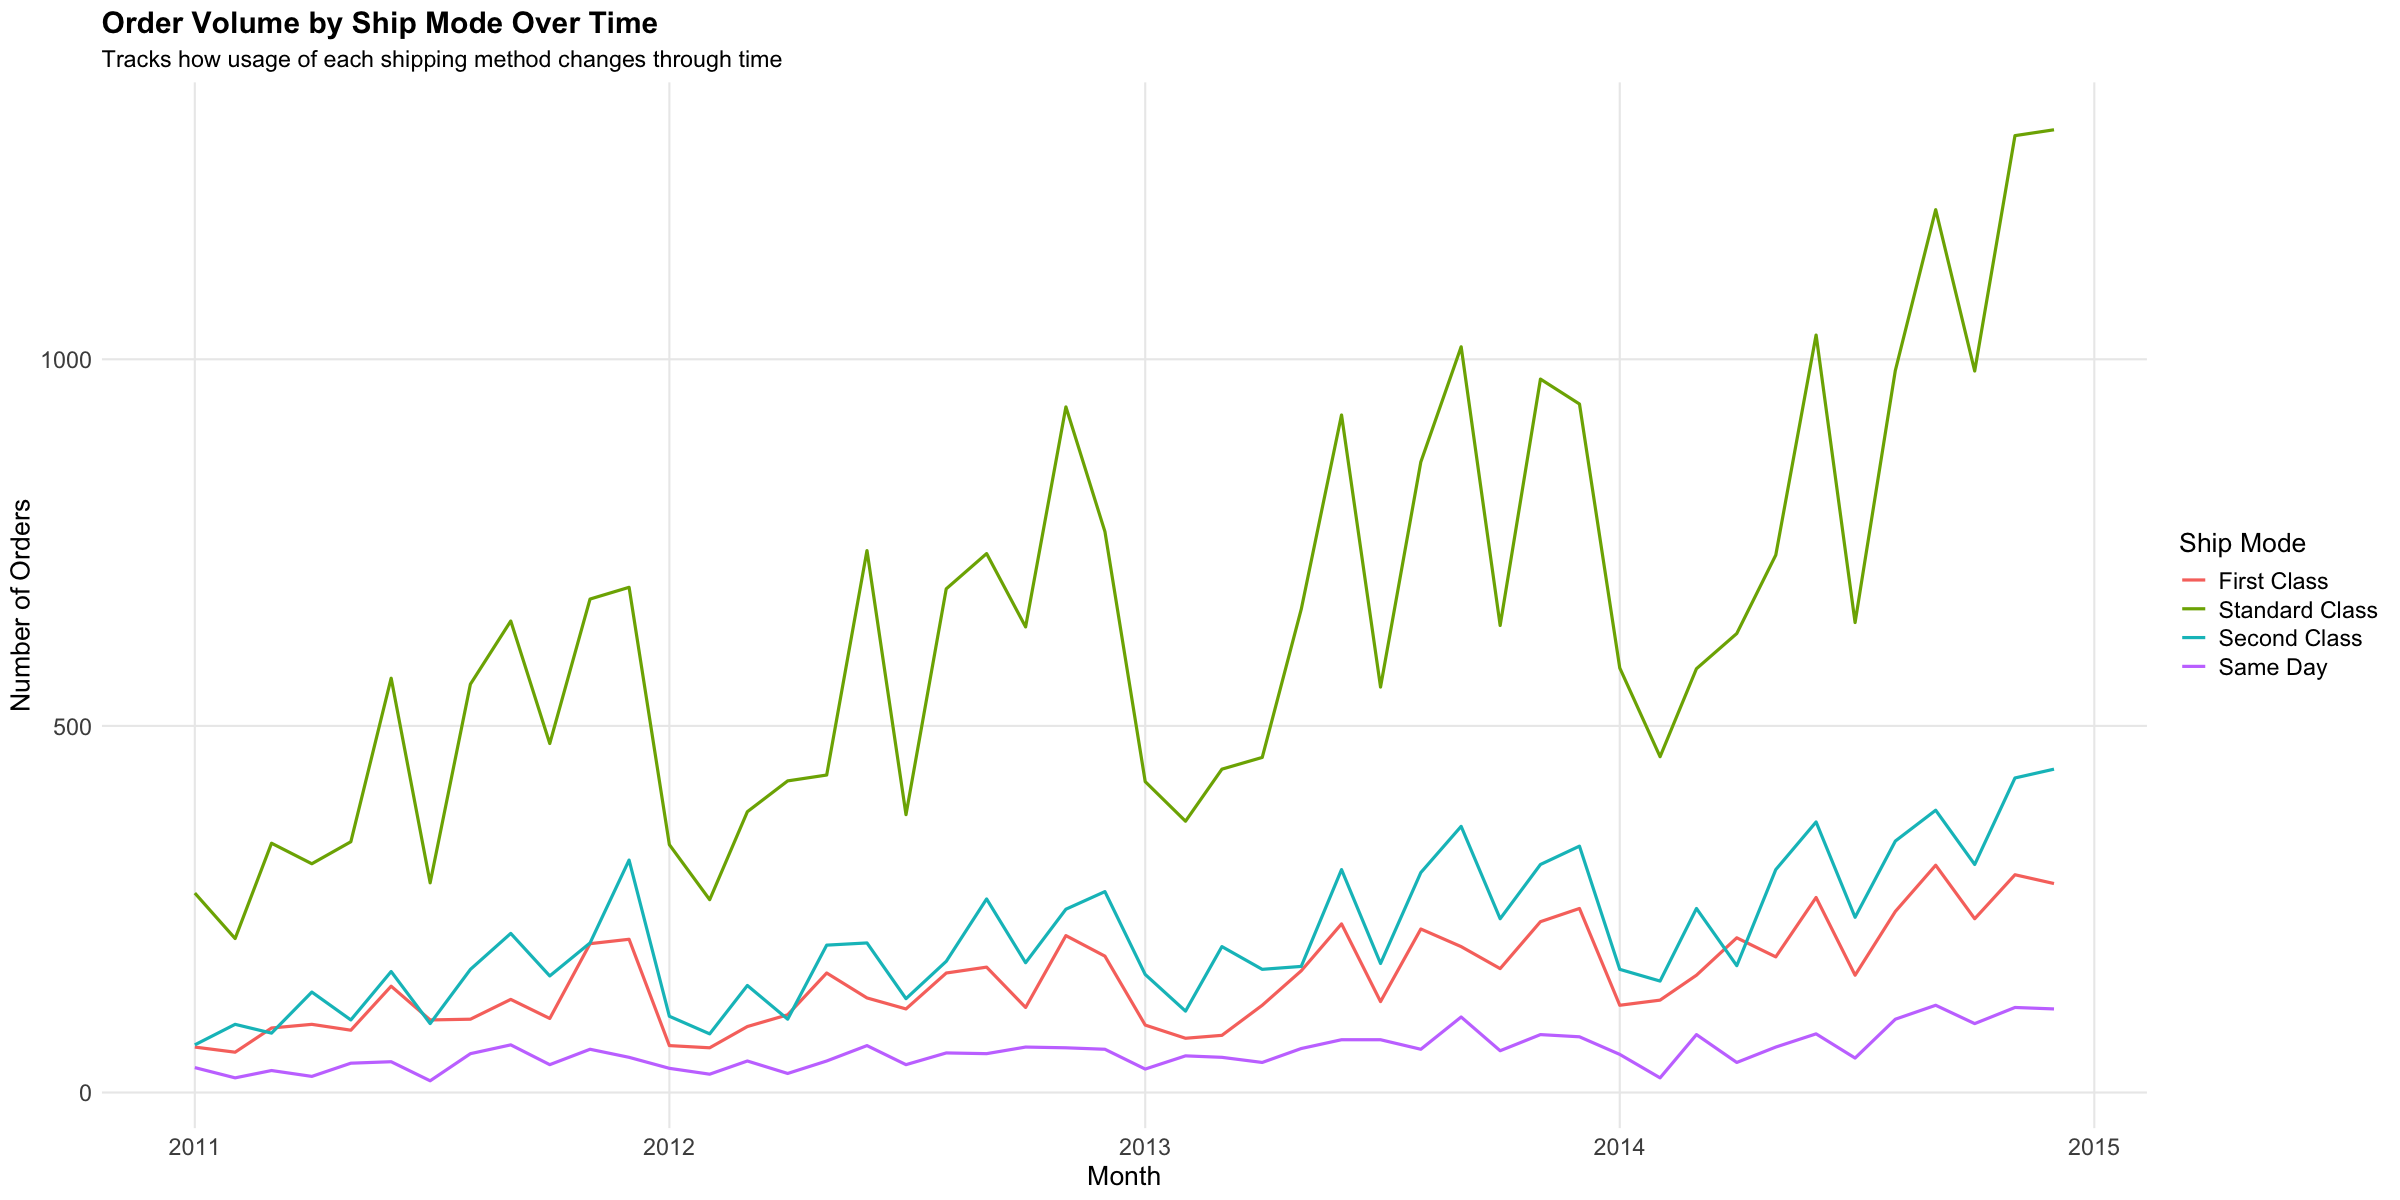

In [ ]:
orders |>
    mutate(order_month = lubridate::floor_date(order_date, "month")) |>
    count(order_month, ship_mode) |>
    ggplot(aes(x = order_month, y = n, color = ship_mode)) +
    geom_line(linewidth = 0.9) +
    labs(
        title = "Order Volume by Ship Mode Over Time",
        subtitle = "Tracks how usage of each shipping method changes through time",
        x = "Month",
        y = "Number of Orders",
        color = "Ship Mode"
    )

### Profit over Time by Ship Mode

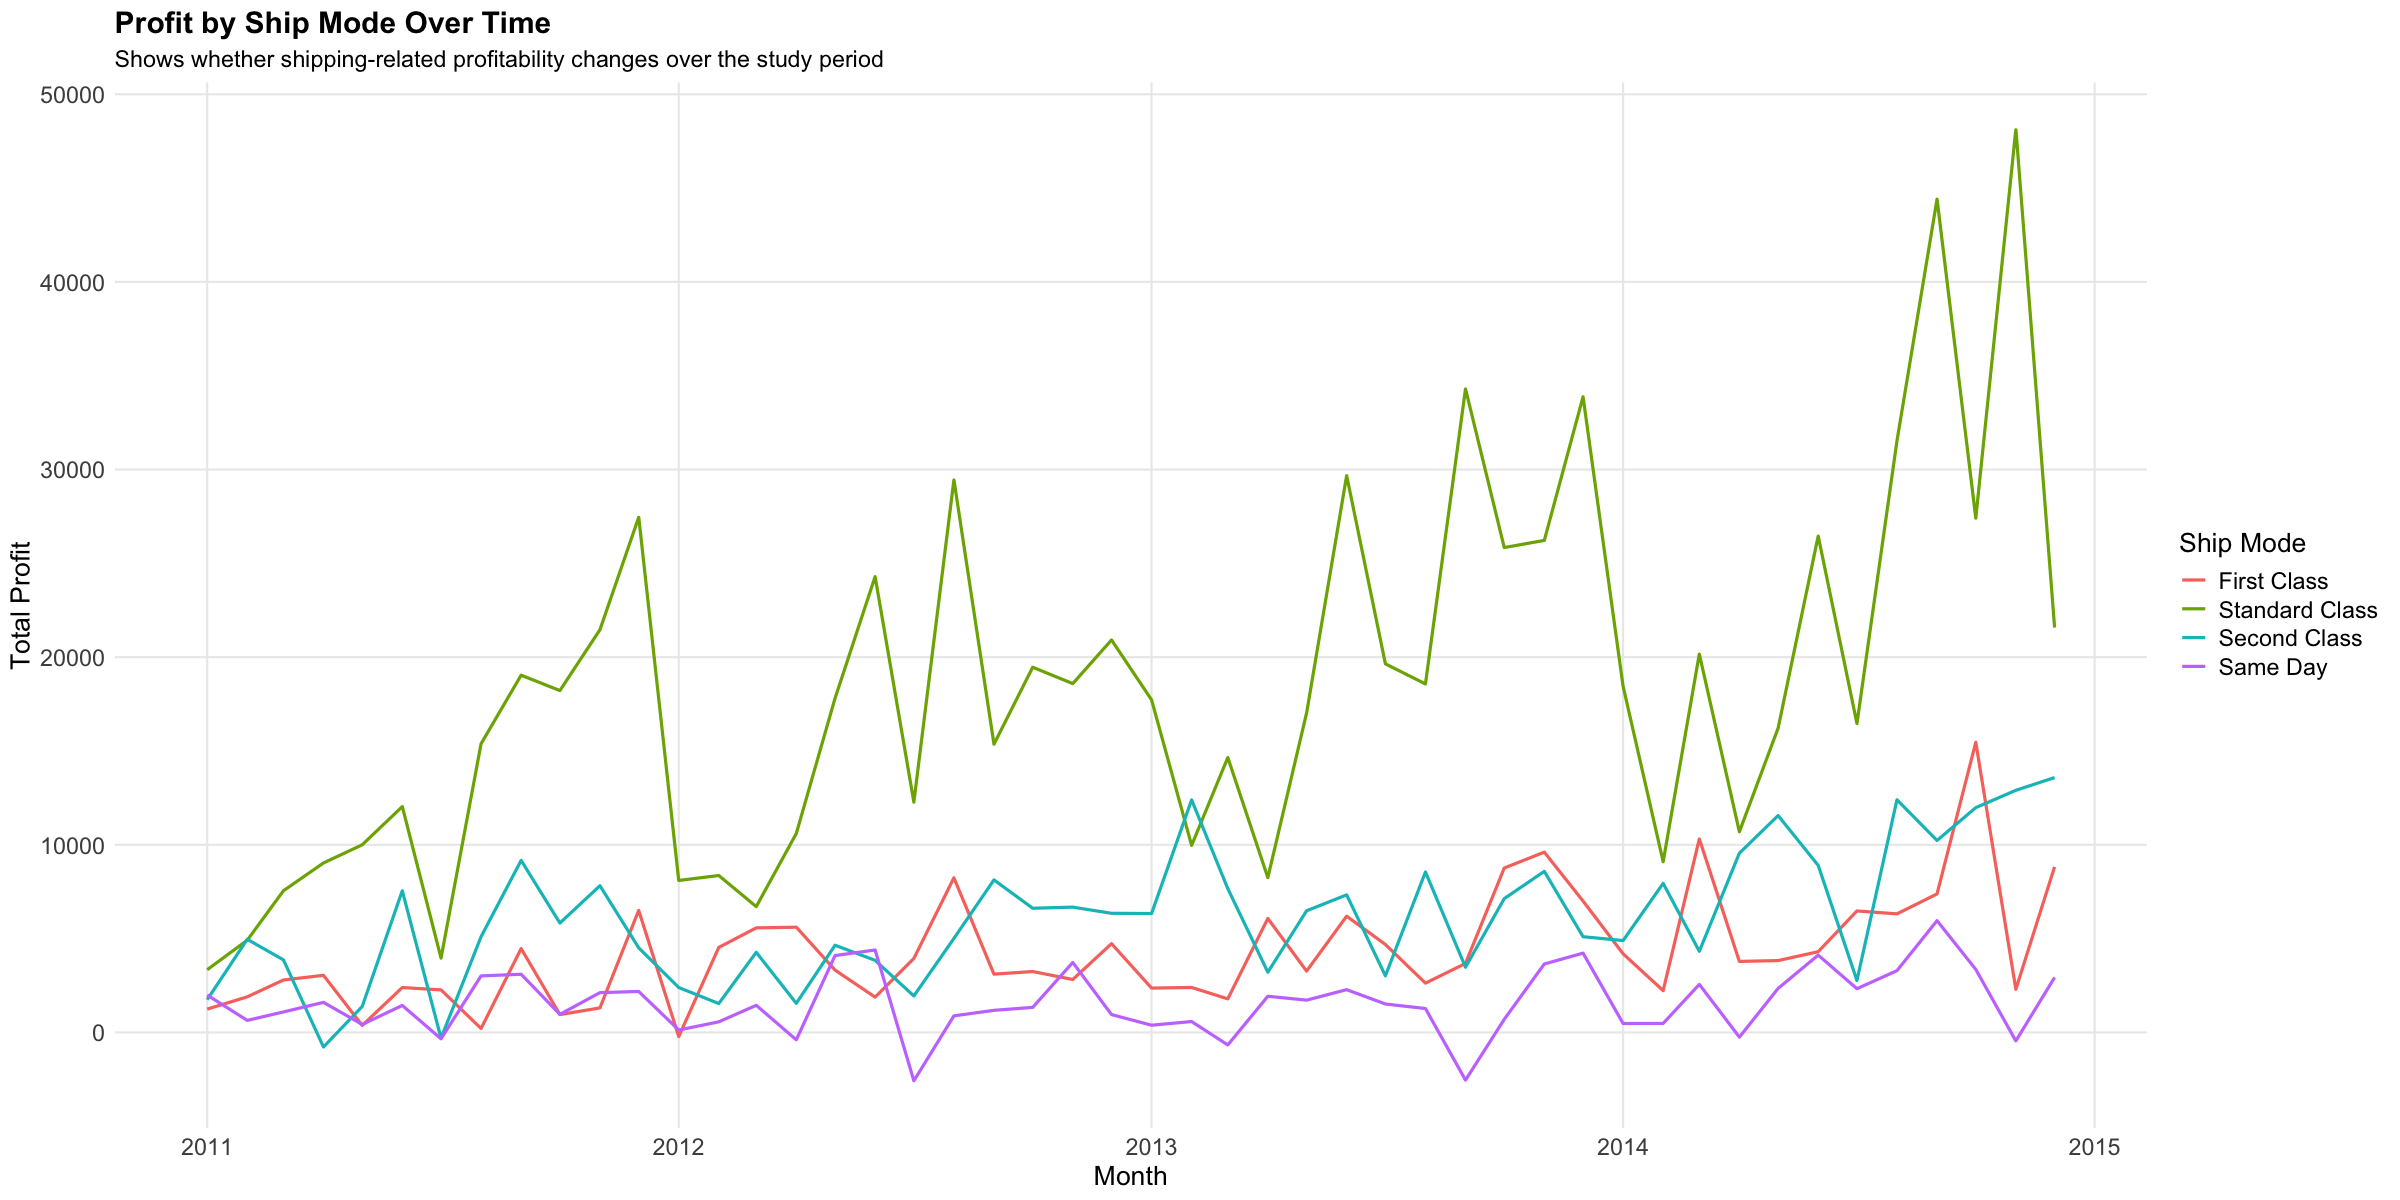

In [ ]:
orders |>
    mutate(order_month = lubridate::floor_date(order_date, "month")) |>
    group_by(order_month, ship_mode) |>
    summarise(total_profit = sum(profit, na.rm = TRUE), .groups = "drop") |>
    ggplot(aes(x = order_month, y = total_profit, color = ship_mode)) +
    geom_line(linewidth = 0.9) +
    labs(
        title = "Profit by Ship Mode Over Time",
        subtitle = "Shows whether shipping-related profitability changes over the study period",
        x = "Month",
        y = "Total Profit",
        color = "Ship Mode"
    )

### Section Interpretation

The temporal section shows whether shipping behavior is stable over time or whether certain ship modes become more or less important during different periods. Volume trends reveal operational shifts in shipping usage, while profit trends show whether those operational shifts are associated with stronger or weaker financial outcomes. If one mode rises in usage without corresponding profit improvement, that may suggest growing operational dependence without equivalent business benefit. If both usage and profit rise together, the mode may be becoming more strategically important.

## Order Priority and Fulfillment Patterns

### Order Count by Priority

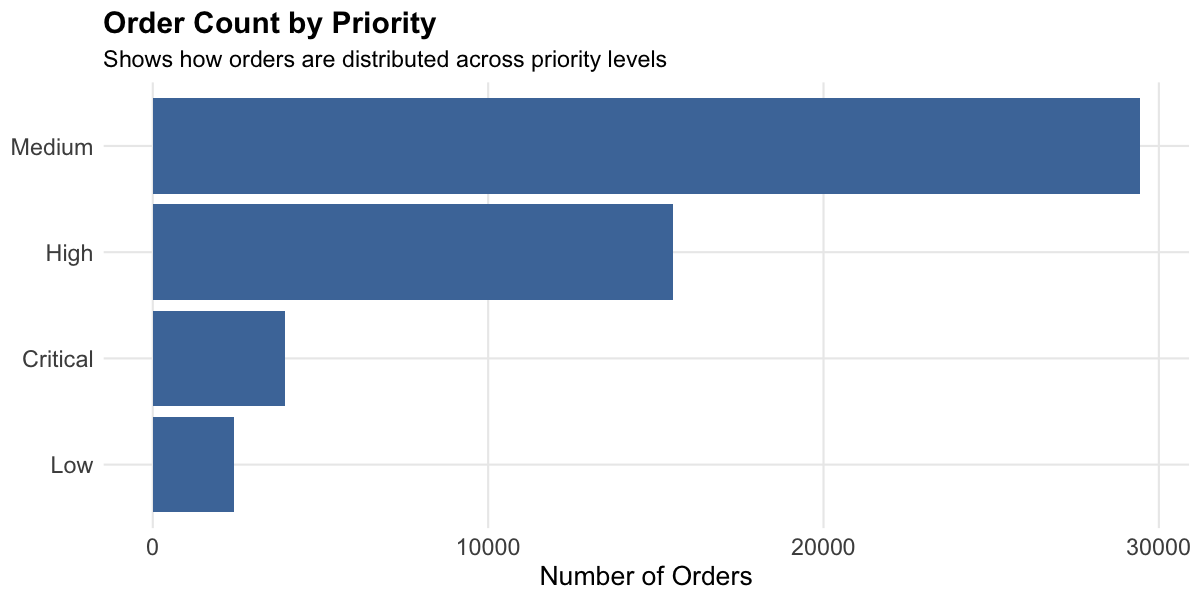

In [42]:
orders %>%
    count(order_priority) %>%
    ggplot(aes(x = reorder(order_priority, n), y = n)) +
    geom_col(fill = ship_blue) +
    coord_flip() +
    labs(
        title = "Order Count by Priority",
        subtitle = "Shows how orders are distributed across priority levels",
        x = NULL,
        y = "Number of Orders"
    )

### Ship Mode by Order Priority

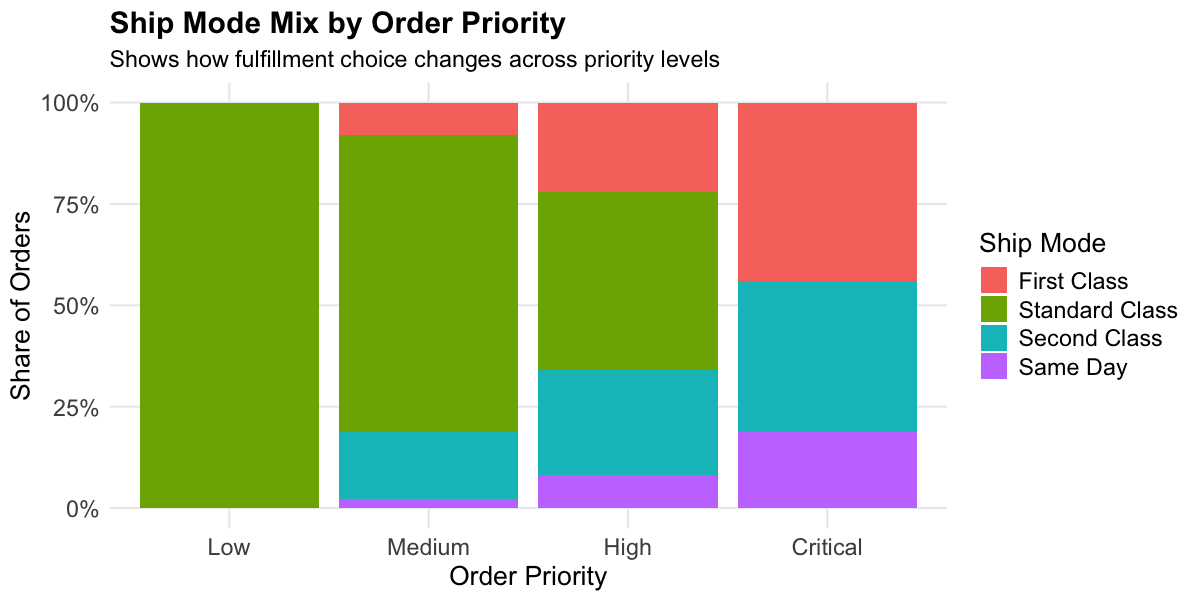

In [44]:
orders %>%
    count(order_priority, ship_mode) %>%
    ggplot(aes(x = order_priority, y = n, fill = ship_mode)) +
    geom_col(position = "fill") +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Ship Mode Mix by Order Priority",
        subtitle = "Shows how fulfillment choice changes across priority levels",
        x = "Order Priority",
        y = "Share of Orders",
        fill = "Ship Mode"
    )

### Average Shipping Cost by Order Priority

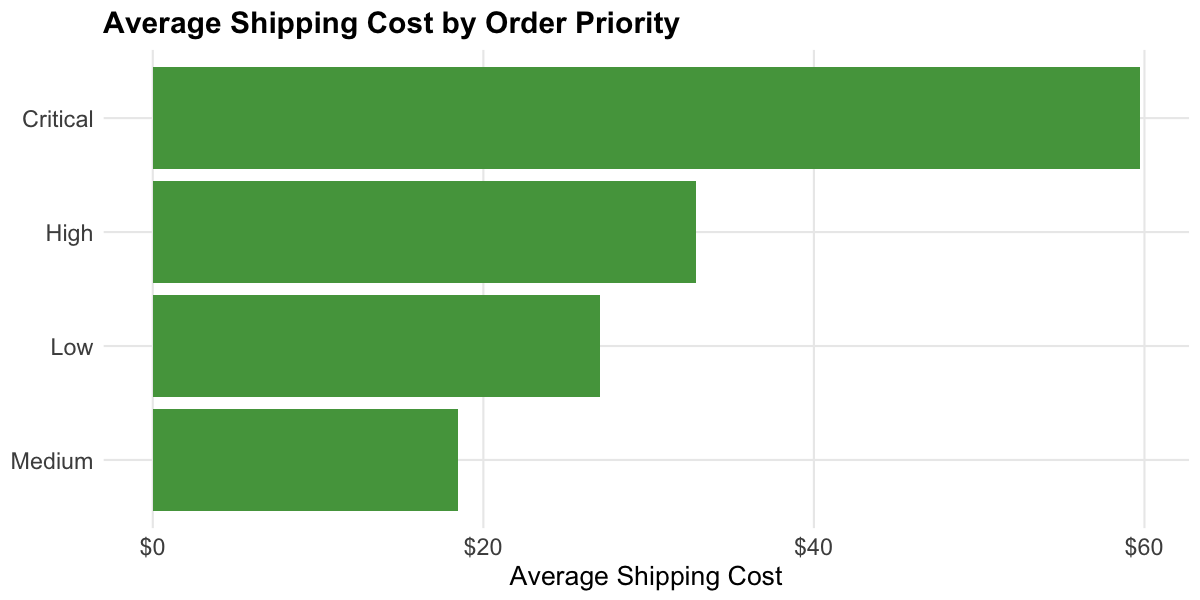

In [47]:
orders %>%
    group_by(order_priority) %>%
    summarise(avg_shipping_cost = mean(shipping_cost, na.rm = TRUE), .groups = "drop") %>%
    ggplot(aes(x = reorder(order_priority, avg_shipping_cost), y = avg_shipping_cost)) +
    geom_col(fill = ship_green) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Average Shipping Cost by Order Priority",
        x = NULL,
        y = "Average Shipping Cost"
    )

### Profit by Order Priority

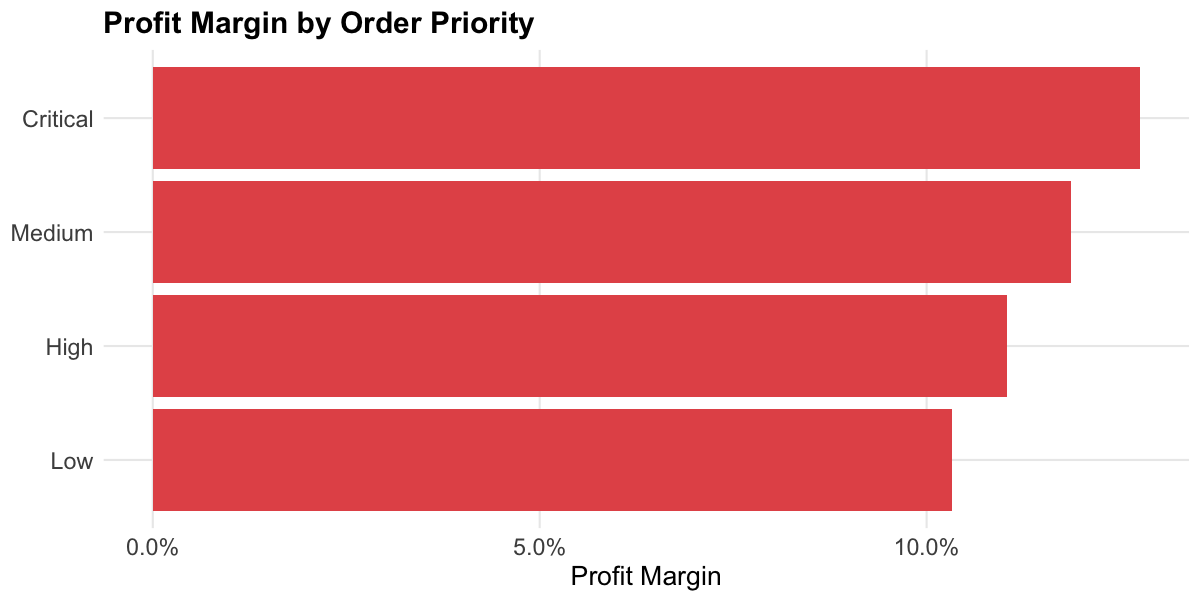

In [48]:
orders %>%
    group_by(order_priority) %>%
    summarise(
        total_sales = sum(sales, na.rm = TRUE),
        total_profit = sum(profit, na.rm = TRUE),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    ) %>%
    ggplot(aes(x = reorder(order_priority, profit_margin), y = profit_margin)) +
    geom_col(fill = ship_red) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 0.1)) +
    labs(
        title = "Profit Margin by Order Priority",
        x = NULL,
        y = "Profit Margin"
    )

### Heatmap: priority x ship mode by sales

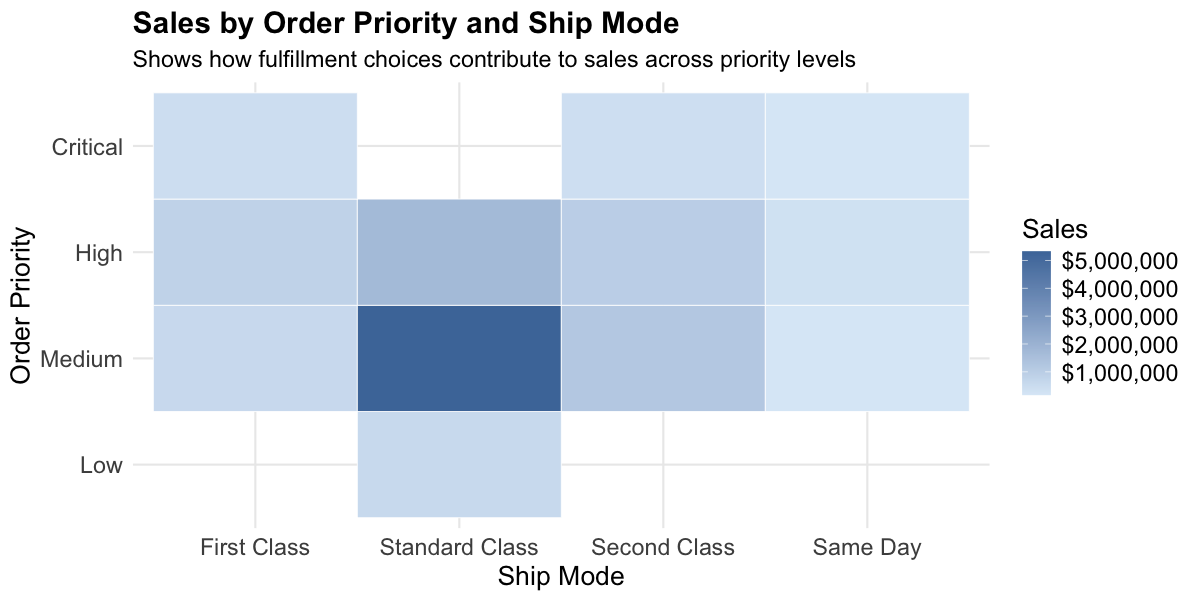

In [49]:
orders %>%
    group_by(order_priority, ship_mode) %>%
    summarise(total_sales = sum(sales, na.rm = TRUE), .groups = "drop") %>%
    ggplot(aes(x = ship_mode, y = order_priority, fill = total_sales)) +
    geom_tile(color = "white") +
    scale_fill_gradient(low = "#DCEAF7", high = "#4C78A8", labels = scales::dollar_format()) +
    labs(
        title = "Sales by Order Priority and Ship Mode",
        subtitle = "Shows how fulfillment choices contribute to sales across priority levels",
        x = "Ship Mode",
        y = "Order Priority",
        fill = "Sales"
    )

### Section Interpretation

Order priority adds an important operational layer to the shipping analysis because it helps explain why different shipping modes may be used. The composition chart shows whether high-priority orders rely more heavily on certain fulfillment methods, while the shipping-cost comparison indicates whether urgency translates into more expensive logistics. The profitability view then tests whether higher-priority orders justify their shipping intensity from a business perspective. Together, these results help distinguish operational necessity from inefficiency and make the shipping analysis more aligned with how fulfillment decisions are actually made.